Descargamos el dataset

In [8]:
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar -P /content/data
!tar -xf /content/data/images.tar -C /content/data

--2026-03-26 20:48:07--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘/content/data/images.tar.3’

images.tar.3        100%[===================>] 756.82M  66.2MB/s    in 10s     

2026-03-26 20:48:17 (73.8 MB/s) - ‘/content/data/images.tar.3’ saved [793579520/793579520]



Importamos todas las librerías primarias para el proyecto. Numpy y matplotlib para manejo de datos y visualización, pathlib para manejar rutas de archivos, y PIL para abrir imágenes.

In [9]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from collections import Counter
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

Antes de construir cualquier modelo necesitamos entender el dataset. Vamos a revisar cuántas razas hay, cuántas imágenes tiene cada una y si está balanceado. Esto es clave porque si hay razas con muy pocas imágenes el modelo va a aprender mal.

In [10]:
DATASET_PATH = Path("/content/data/Images")

razas = sorted([d.name for d in DATASET_PATH.iterdir() if d.is_dir()])
conteo = {r: len(list((DATASET_PATH / r).glob("*.jpg"))) for r in razas}
valores = list(conteo.values())

print(f"Total razas: {len(razas)}")
print(f"Total imágenes: {sum(valores)}")
print(f"Mín: {min(valores)} | Máx: {max(valores)} | Promedio: {np.mean(valores):.1f}")

Total razas: 120
Total imágenes: 20580
Mín: 148 | Máx: 252 | Promedio: 171.5


Tenemos 120 razas con un total de 20,580 imágenes. El promedio es de 171 imágenes por raza, y la diferencia entre el mínimo (148) y el máximo (252), lo que significa que el dataset está bastante balanceado.

Graficamos la distribución de imágenes por raza para confirmar visualmente que el dataset está balanceado, y luego vemos algunas imágenes para entender qué tan variadas son.

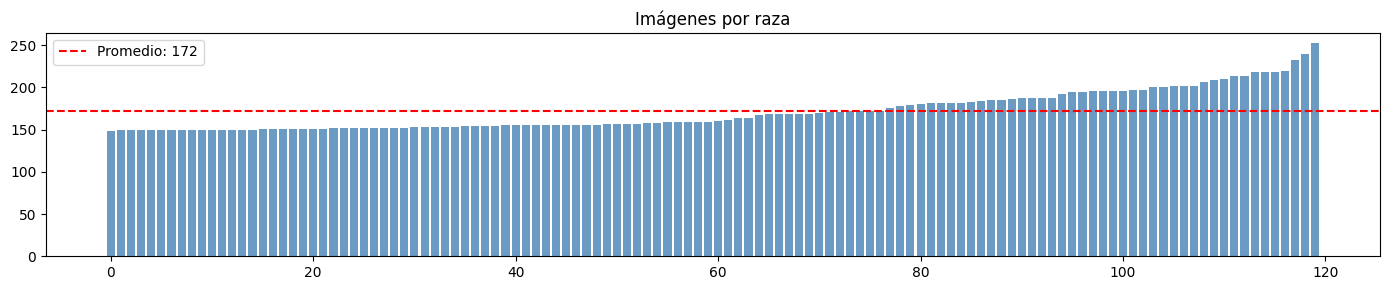

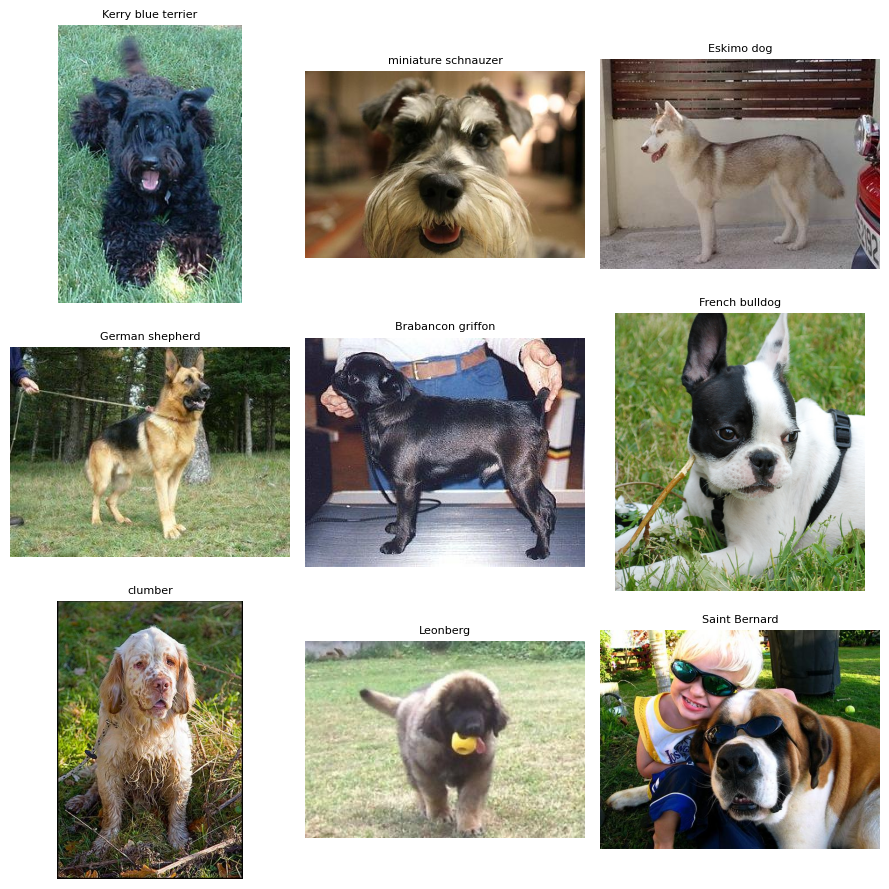

In [11]:
# Distribución por raza
plt.figure(figsize=(14, 3))
plt.bar(range(len(valores)), sorted(valores), color='steelblue', alpha=0.8)
plt.axhline(np.mean(valores), color='red', linestyle='--', label=f'Promedio: {np.mean(valores):.0f}')
plt.title("Imágenes por raza")
plt.legend()
plt.tight_layout()
plt.show()

# Muestra visual de imágenes
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, raza in zip(axes.flatten(), random.sample(razas, 9)):
    img = Image.open(random.choice(list((DATASET_PATH / raza).glob("*.jpg")))).convert("RGB")
    ax.imshow(img)
    ax.set_title(raza.split("-", 1)[-1].replace("_", " "), fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

Al revisar la distribución se puede ver que la mayoría de razas ronda las 150-170 imágenes, y unas pocas llegan hasta 252. La diferencia no es tan grande como para preocuparse, el dataset está bastante parejo. Con esto podemos seguir sin necesidad de hacer nada especial para balancear las clases.

Vamos a identificar exactamente cuáles razas tienen más imágenes que el promedio y por cuánto se pasan.

In [12]:
promedio = np.mean(valores)

razas_sobre_promedio = {r: v for r, v in conteo.items() if v > promedio}
razas_ordenadas = sorted(razas_sobre_promedio.items(), key=lambda x: x[1], reverse=True)

print(f"Razas sobre el promedio ({promedio:.0f}): {len(razas_ordenadas)}\n")
for raza, cantidad in razas_ordenadas[:10]:
    nombre = raza.split("-", 1)[-1].replace("_", " ")
    print(f"{nombre}: {cantidad} imágenes")

Razas sobre el promedio (172): 47

Maltese dog: 252 imágenes
Afghan hound: 239 imágenes
Scottish deerhound: 232 imágenes
Pomeranian: 219 imágenes
Irish wolfhound: 218 imágenes
Bernese mountain dog: 218 imágenes
Samoyed: 218 imágenes
Shih-Tzu: 214 imágenes
Great Pyrenees: 213 imágenes
Leonberg: 210 imágenes


De las 120 razas, 47 están por encima del promedio. La que más tiene es el Maltese dog con 252 imágenes y la que menos tiene llega a 148. Una diferencia de 104 imágenes entre el máximo y el mínimo no es algo que nos deba preocupar, así que podemos seguir sin tocar nada.

Antes de entrenar el modelo necesitamos revisar los tamaños de las imágenes. Esto nos ayuda a decidir a qué resolución vamos a redimensionar todo, porque el modelo necesita que todas las imágenes tengan el mismo tamaño.

In [13]:
tamaños = []
for raza in random.sample(razas, 20):
    for img_path in list((DATASET_PATH / raza).glob("*.jpg"))[:5]:
        img = Image.open(img_path)
        tamaños.append(img.size)

anchos = [t[0] for t in tamaños]
altos = [t[1] for t in tamaños]

print(f"Ancho  — Mín: {min(anchos)} | Máx: {max(anchos)} | Promedio: {np.mean(anchos):.0f}")
print(f"Alto   — Mín: {min(altos)} | Máx: {max(altos)} | Promedio: {np.mean(altos):.0f}")

Ancho  — Mín: 200 | Máx: 727 | Promedio: 432
Alto   — Mín: 150 | Máx: 500 | Promedio: 364


Las imágenes tienen tamaños muy variados, desde 148px hasta 1797px de ancho. Esto significa que no podemos pasarlas directo al modelo, hay que redimensionarlas todas al mismo tamaño. Vamos a usar 224x224 porque es el tamaño que esperan los modelos preentrenados que vamos a usar más adelante.

Ahora vamos a preparar el dataset para el modelo. Vamos a redimensionar todas las imágenes a 224x224, normalizar los píxeles entre 0 y 1, y dividir el dataset en train, validación y test.

In [14]:
from sklearn.model_selection import train_test_split

rutas = []
etiquetas = []

for idx, raza in enumerate(razas):
    for img_path in (DATASET_PATH / raza).glob("*.jpg"):
        rutas.append(str(img_path))
        etiquetas.append(idx)

# División 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(rutas, etiquetas, test_size=0.2, random_state=42, stratify=etiquetas)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train:      {len(X_train)} imágenes")
print(f"Validación: {len(X_val)} imágenes")
print(f"Test:       {len(X_test)} imágenes")    

Train:      16464 imágenes
Validación: 2058 imágenes
Test:       2058 imágenes


La división quedó bien. 16,464 imágenes para entrenar y 2,058 para validación y test. El stratify garantiza que las 120 razas estén representadas en cada conjunto.

Antes de pasarle las imágenes al modelo necesitamos que todas tengan el mismo tamaño. Usamos 128x128 porque conserva buen detalle sin ser tan pesado. También normalizamos los píxeles entre 0 y 1.

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

def cargar_imagen(ruta, etiqueta):
    img = tf.io.read_file(ruta)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = img / 255.0
    return img, etiqueta

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(cargar_imagen).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(cargar_imagen).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Datasets creados con 128x128")

Datasets creados con 128x128


Como tenemos pocas imágenes por raza aplicamos data augmentation al conjunto de entrenamiento. El modelo va a ver las imágenes volteadas, rotadas y con brillo diferente para que no se memorice las fotos.

Ajustamos el tamaño de las imágenes a 128x128, un tamaño que conserva más detalle que 64x64 sin ser tan pesado como 224x224.



In [26]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
])

def cargar_imagen_aumentada(ruta, etiqueta):
    img, etiqueta = cargar_imagen(ruta, etiqueta)
    img = data_augmentation(img, training=True)
    return img, etiqueta

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(cargar_imagen_aumentada)
train_ds = train_ds.shuffle(1000)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

print("Data augmentation aplicado al entrenamiento")

Data augmentation aplicado al entrenamiento


Construimos la CNN con 4 bloques convolucionales. Cada bloque tiene Conv2D para detectar características, BatchNormalization para estabilizar el entrenamiento y MaxPooling para reducir el tamaño. Al final GlobalAveragePooling2D reduce todo a un vector sin explotar los parámetros.



In [27]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(120, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compilamos con Adam y sparse_categorical_crossentropy porque las etiquetas son números enteros del 0 al 119.



In [28]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    epochs=20,
    validation_data=val_ds
)

Epoch 1/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 110s 190ms/step - accuracy: 0.0086 - loss: 4.9639 - val_accuracy: 0.0102 - val_loss: 4.8132
Epoch 2/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 99s 184ms/step - accuracy: 0.0105 - loss: 4.8495 - val_accuracy: 0.0087 - val_loss: 4.8362
Epoch 3/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 99s 182ms/step - accuracy: 0.0095 - loss: 4.7994 - val_accuracy: 0.0107 - val_loss: 4.7826
Epoch 4/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 98s 182ms/step - accuracy: 0.0115 - loss: 4.7878 - val_accuracy: 0.0170 - val_loss: 4.7825
Epoch 5/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 99s 182ms/step - accuracy: 0.0118 - loss: 4.7826 - val_accuracy: 0.0126 - val_loss: 4.7799
Epoch 6/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 99s 182ms/step - accuracy: 0.0116 - loss: 4.7830 - val_accuracy: 0.0121 - val_loss: 4.7798
Epoch 7/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 99s 182ms/step - accuracy: 0.0122 - loss: 4.7827 - val_accuracy: 0.0121 - val_loss: 4.7795
Epoch 8/20
515/515 ━━━━━━━━━━━━━━━━━━━━ 100s 184ms/step - accuracy: 0.0120 - loss:

El modelo terminó con un accuracy de 1.23% en entrenamiento y 1.21% en validación. Ambos valores son prácticamente iguales lo que indica que no hay overfitting, pero el modelo tampoco aprendió bien a distinguir las razas. Esto se debe principalmente a la complejidad del problema, 120 razas de perros muy similares entre sí con pocas imágenes por clase es un reto alto para una CNN desde cero.

In [29]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Una vez termine el entrenamiento vamos a graficar el accuracy y el loss tanto de train como de validación para ver si el modelo está aprendiendo bien o si hay overfitting.

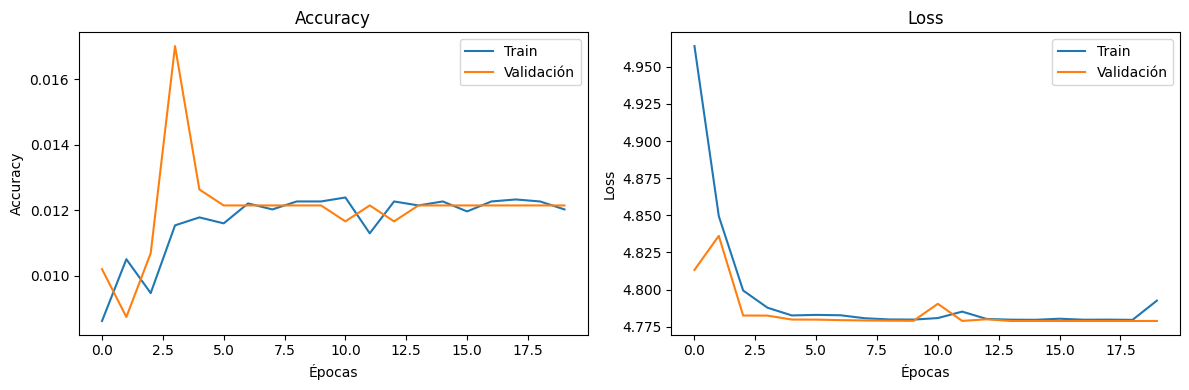

In [30]:
# Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

Ahora evaluamos el modelo con el conjunto de test, que son imágenes que el modelo nunca vio durante el entrenamiento. También generamos la matriz de confusión para ver en qué razas se equivoca más.

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.0121 - loss: 4.7788
Accuracy en test: 0.0121
Loss en test: 4.7788


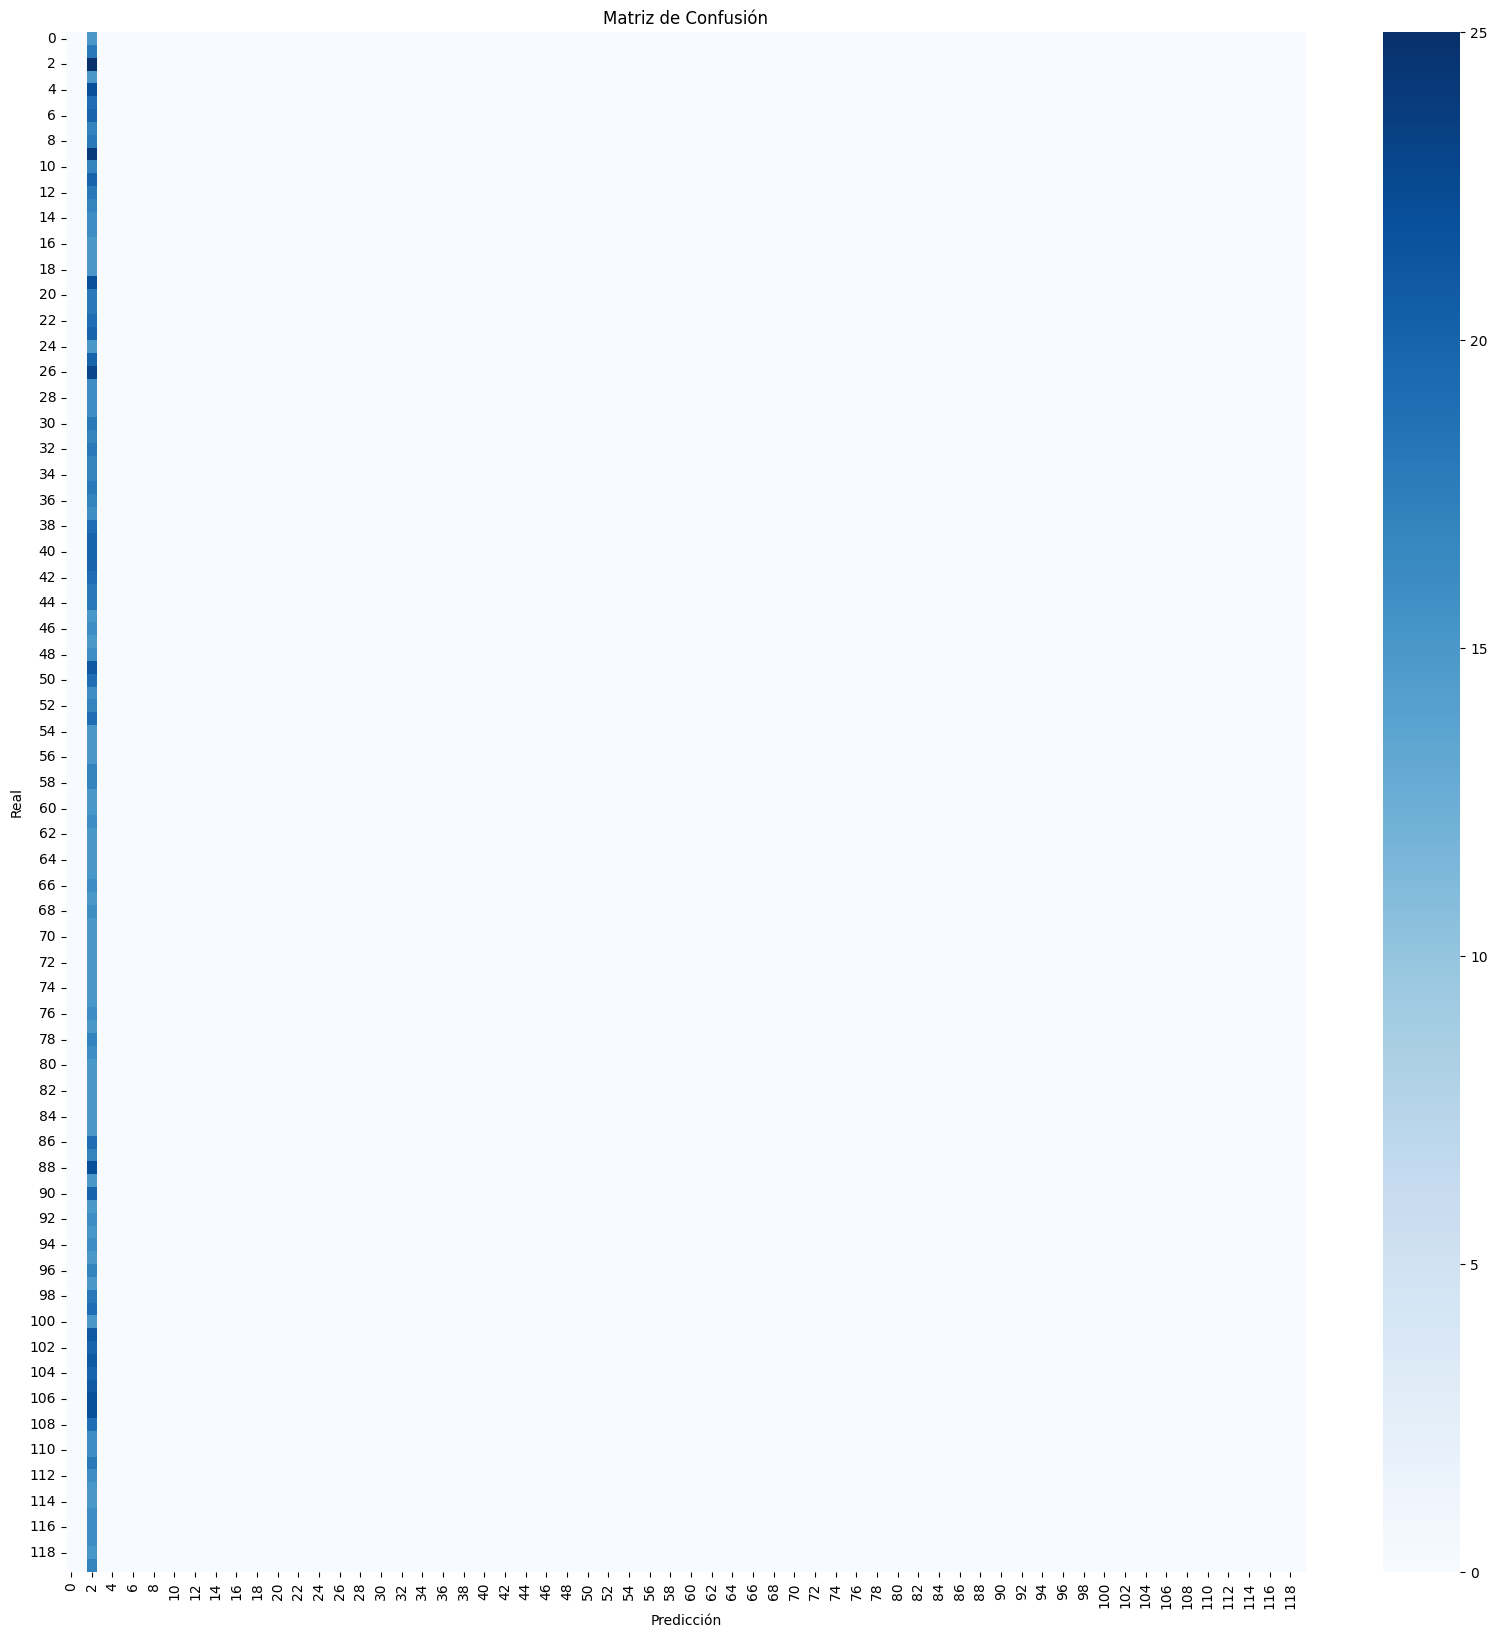

In [31]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Evaluación general
loss, accuracy = model.evaluate(test_ds)
print(f"Accuracy en test: {accuracy:.4f}")
print(f"Loss en test: {loss:.4f}")

# Predicciones
y_pred = []
y_true = []

for imgs, labels in test_ds:
    preds = model.predict(imgs, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Matriz de Confusión')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

Guardamos el modelo en formato .keras para poder cargarlo después sin necesidad de volver a entrenar.

In [34]:
import tensorflow as tf

# Cargar tu modelo original
model = tf.keras.models.load_model("modelo_perros.keras", compile=False)

# GUARDARLO BIEN (compatible con TF 2.15)
model.save("modelo_perros_fixed.keras")

In [35]:
from google.colab import files
files.download("modelo_perros_fixed.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>